In [13]:
"""
ANÁLISIS EXPLORATORIO DE DATOS (EDA) - TFM
Visualización y comprensión de patrones de morosidad
Autor: Francisco Álvarez
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 60)
print("📊 ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 60)

📊 ANÁLISIS EXPLORATORIO DE DATOS (EDA)


In [14]:
# Cargar los 3 datasets
print("\n📂 Cargando datos...")

df_clientes = pd.read_csv('../datos/clientes.csv')
df_facturas = pd.read_csv('../datos/facturas.csv')
df_historial = pd.read_csv('../datos/historial_pagos.csv')

# Convertir fechas
df_facturas['fecha_emision'] = pd.to_datetime(df_facturas['fecha_emision'])
df_facturas['vencimiento'] = pd.to_datetime(df_facturas['vencimiento'])

print(f"✅ Clientes: {len(df_clientes)} registros")
print(f"✅ Facturas: {len(df_facturas)} registros")
print(f"✅ Historial: {len(df_historial)} registros")

# Vista previa
print("\n📋 Primeras 3 facturas:")
df_facturas.head(3)


📂 Cargando datos...
✅ Clientes: 100 registros
✅ Facturas: 500 registros
✅ Historial: 100 registros

📋 Primeras 3 facturas:


,factura_id,cliente_id,importe,fecha_emision,vencimiento,dias_retraso,estado,pagada
0,FAC-2025-0001,CLI_088,405.38,2025-12-06,2026-01-20,0,Pagada,True
1,FAC-2025-0002,CLI_069,6797.11,2025-12-24,2026-01-23,0,Pagada,True
2,FAC-2025-0003,CLI_009,8234.64,2025-08-20,2025-09-19,0,Pagada,True


In [15]:
print("\n" + "=" * 60)
print("📈 ESTADÍSTICAS DESCRIPTIVAS GENERALES")
print("=" * 60)

# Resumen de facturas
print("\n💰 FACTURAS:")
print(f"   Total facturas: {len(df_facturas)}")
print(f"   Importe total: {df_facturas['importe'].sum():,.2f}€")
print(f"   Importe promedio: {df_facturas['importe'].mean():,.2f}€")
print(f"   Importe mediano: {df_facturas['importe'].median():,.2f}€")

# Estados
print(f"\n📊 DISTRIBUCIÓN POR ESTADO:")
estado_counts = df_facturas['estado'].value_counts()
for estado, count in estado_counts.items():
    porcentaje = (count / len(df_facturas)) * 100
    print(f"   {estado}: {count} ({porcentaje:.1f}%)")

# Deuda pendiente
deuda_pendiente = df_facturas[~df_facturas['pagada']]['importe'].sum()
print(f"\n💸 DEUDA PENDIENTE TOTAL: {deuda_pendiente:,.2f}€")

# Morosidad
tasa_morosidad = (df_facturas['estado'] == 'Vencida').mean()
print(f"📉 TASA DE MOROSIDAD: {tasa_morosidad:.1%}")


📈 ESTADÍSTICAS DESCRIPTIVAS GENERALES

💰 FACTURAS:
   Total facturas: 500
   Importe total: 1,836,441.18€
   Importe promedio: 3,672.88€
   Importe mediano: 3,308.97€

📊 DISTRIBUCIÓN POR ESTADO:
   Vencida: 237 (47.4%)
   Pagada: 173 (34.6%)
   Pendiente: 90 (18.0%)

💸 DEUDA PENDIENTE TOTAL: 1,198,672.20€
📉 TASA DE MOROSIDAD: 47.4%



------------------------------------------------------------
📊 VISUALIZACIÓN 1: Distribución de importes
------------------------------------------------------------


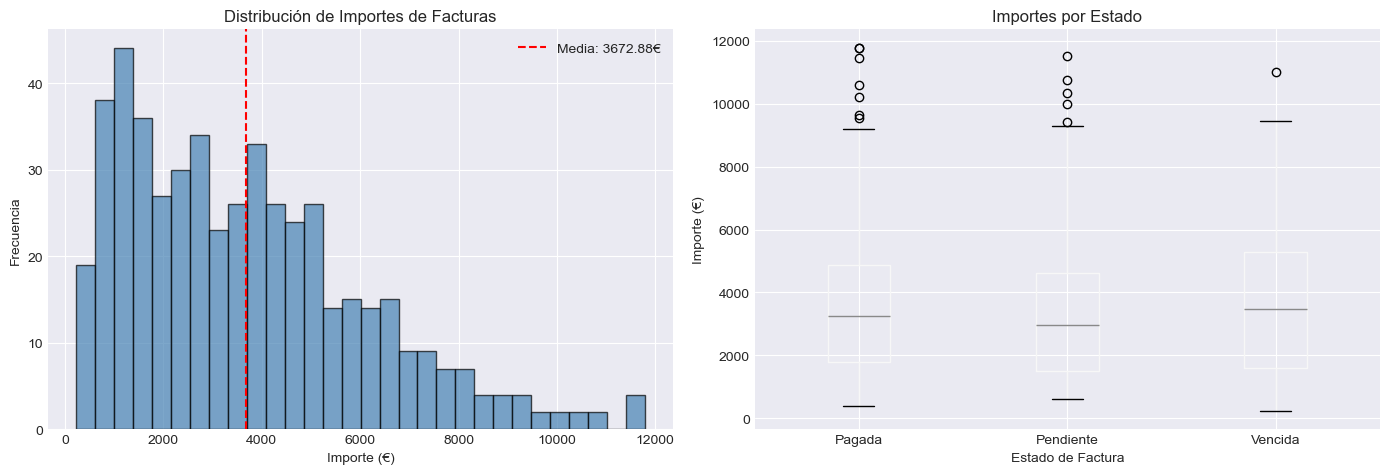

✅ Gráficos generados


In [16]:
print("\n" + "-" * 60)
print("📊 VISUALIZACIÓN 1: Distribución de importes")
print("-" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_facturas['importe'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Importe (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Importes de Facturas')
axes[0].axvline(df_facturas['importe'].mean(), color='red', linestyle='--', 
                label=f'Media: {df_facturas["importe"].mean():.2f}€')
axes[0].legend()

# Boxplot por estado
df_facturas.boxplot(column='importe', by='estado', ax=axes[1])
axes[1].set_xlabel('Estado de Factura')
axes[1].set_ylabel('Importe (€)')
axes[1].set_title('Importes por Estado')
plt.suptitle('')  # Quitar título automático

plt.tight_layout()
plt.show()

print(f"✅ Gráficos generados")


------------------------------------------------------------
📊 VISUALIZACIÓN 1: Distribución de importes
------------------------------------------------------------


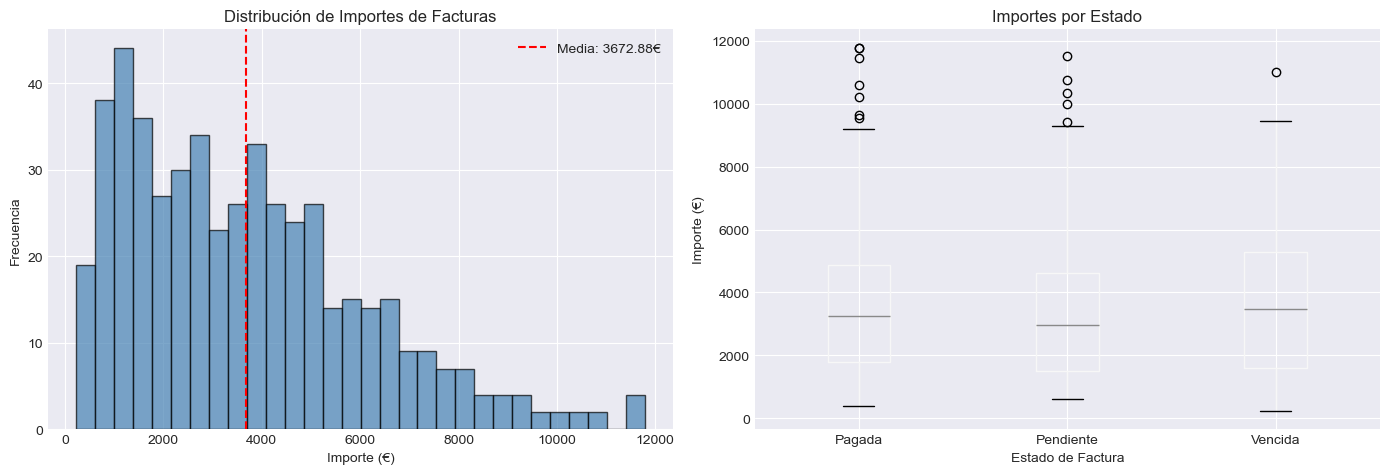

✅ Gráficos generados


In [17]:
print("\n" + "-" * 60)
print("📊 VISUALIZACIÓN 1: Distribución de importes")
print("-" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_facturas['importe'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Importe (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Importes de Facturas')
axes[0].axvline(df_facturas['importe'].mean(), color='red', linestyle='--', 
                label=f'Media: {df_facturas["importe"].mean():.2f}€')
axes[0].legend()

# Boxplot por estado
df_facturas.boxplot(column='importe', by='estado', ax=axes[1])
axes[1].set_xlabel('Estado de Factura')
axes[1].set_ylabel('Importe (€)')
axes[1].set_title('Importes por Estado')
plt.suptitle('')  # Quitar título automático

plt.tight_layout()
plt.show()

print(f"✅ Gráficos generados")


------------------------------------------------------------
📊 VISUALIZACIÓN 2: Morosidad por sector
------------------------------------------------------------


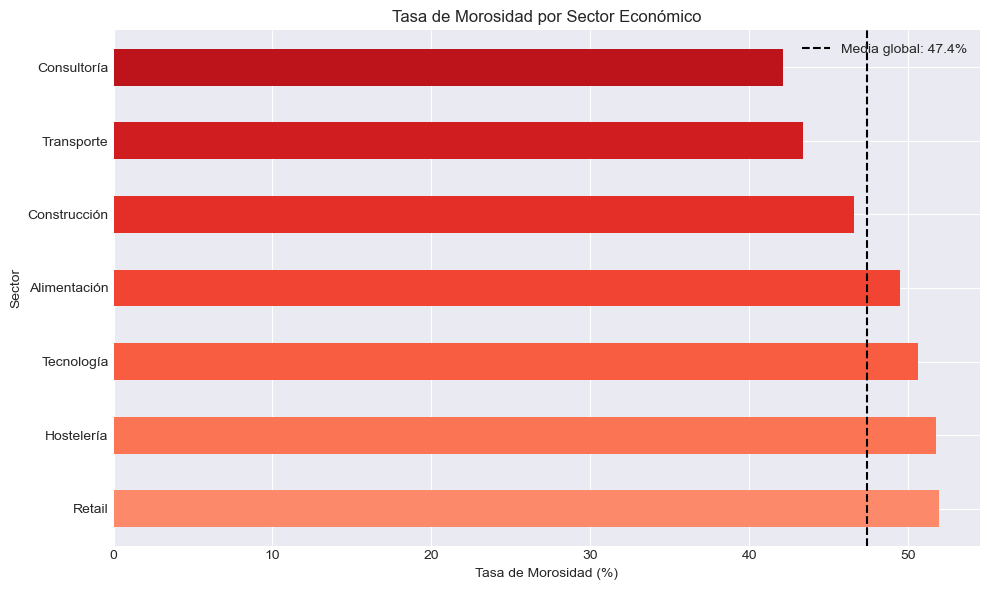


📊 Ranking de morosidad por sector:
   Retail: 51.9%
   Hostelería: 51.7%
   Tecnología: 50.6%
   Alimentación: 49.5%
   Construcción: 46.6%
   Transporte: 43.4%
   Consultoría: 42.1%


In [18]:
print("\n" + "-" * 60)
print("📊 VISUALIZACIÓN 2: Morosidad por sector")
print("-" * 60)

# Unir facturas con clientes para obtener el sector
df_facturas_sector = df_facturas.merge(df_clientes[['cliente_id', 'sector']], on='cliente_id')

# Calcular morosidad por sector
morosidad_sector = df_facturas_sector.groupby('sector').apply(
    lambda x: (x['estado'] == 'Vencida').sum() / len(x) * 100
).sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.8, len(morosidad_sector)))
morosidad_sector.plot(kind='barh', color=colors)
plt.xlabel('Tasa de Morosidad (%)')
plt.ylabel('Sector')
plt.title('Tasa de Morosidad por Sector Económico')
plt.axvline(tasa_morosidad * 100, color='black', linestyle='--', 
            label=f'Media global: {tasa_morosidad:.1%}')
plt.legend()
plt.tight_layout()
plt.show()

print("\n📊 Ranking de morosidad por sector:")
for sector, tasa in morosidad_sector.items():
    print(f"   {sector}: {tasa:.1f}%")


------------------------------------------------------------
📊 VISUALIZACIÓN 3: Análisis de días de retraso
------------------------------------------------------------


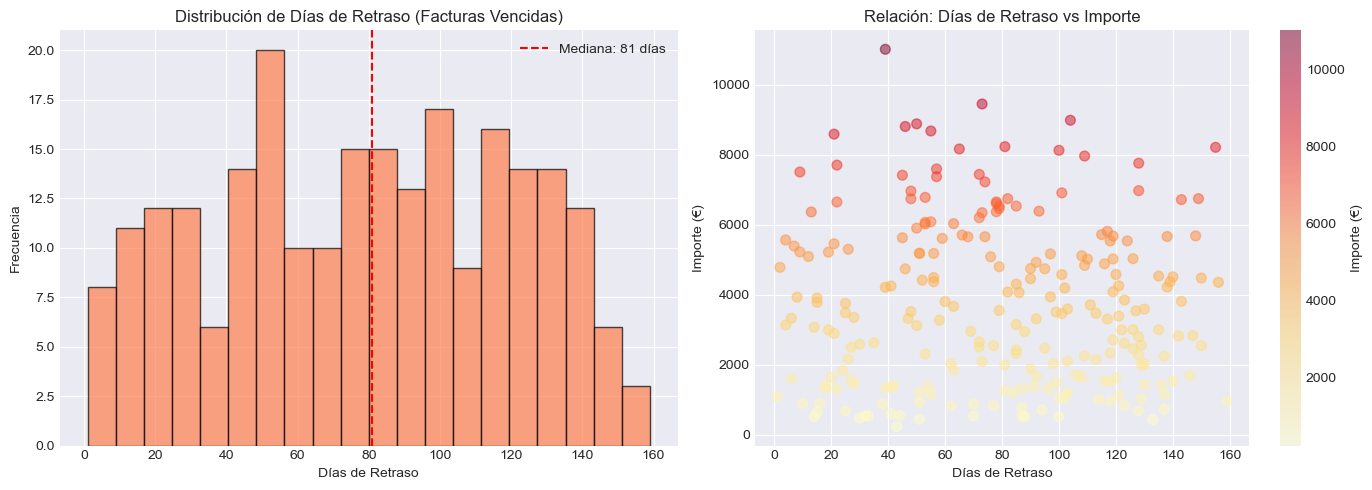


📊 Estadísticas de retraso:
   Media: 78.8 días
   Mediana: 81.0 días
   Máximo: 159 días
   Percentil 90: 131.2 días


In [19]:
print("\n" + "-" * 60)
print("📊 VISUALIZACIÓN 3: Análisis de días de retraso")
print("-" * 60)

# Solo facturas vencidas
facturas_vencidas = df_facturas[df_facturas['estado'] == 'Vencida']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de días de retraso
axes[0].hist(facturas_vencidas['dias_retraso'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Días de Retraso')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Días de Retraso (Facturas Vencidas)')
axes[0].axvline(facturas_vencidas['dias_retraso'].median(), color='red', linestyle='--',
                label=f'Mediana: {facturas_vencidas["dias_retraso"].median():.0f} días')
axes[0].legend()

# Relación importe vs días de retraso
scatter = axes[1].scatter(facturas_vencidas['dias_retraso'], 
                          facturas_vencidas['importe'],
                          alpha=0.5, c=facturas_vencidas['importe'], 
                          cmap='YlOrRd', s=50)
axes[1].set_xlabel('Días de Retraso')
axes[1].set_ylabel('Importe (€)')
axes[1].set_title('Relación: Días de Retraso vs Importe')
plt.colorbar(scatter, ax=axes[1], label='Importe (€)')

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de retraso:")
print(f"   Media: {facturas_vencidas['dias_retraso'].mean():.1f} días")
print(f"   Mediana: {facturas_vencidas['dias_retraso'].median():.1f} días")
print(f"   Máximo: {facturas_vencidas['dias_retraso'].max():.0f} días")
print(f"   Percentil 90: {facturas_vencidas['dias_retraso'].quantile(0.90):.1f} días")


------------------------------------------------------------
📊 VISUALIZACIÓN 5: Evolución temporal
------------------------------------------------------------


<Figure size 1200x600 with 0 Axes>

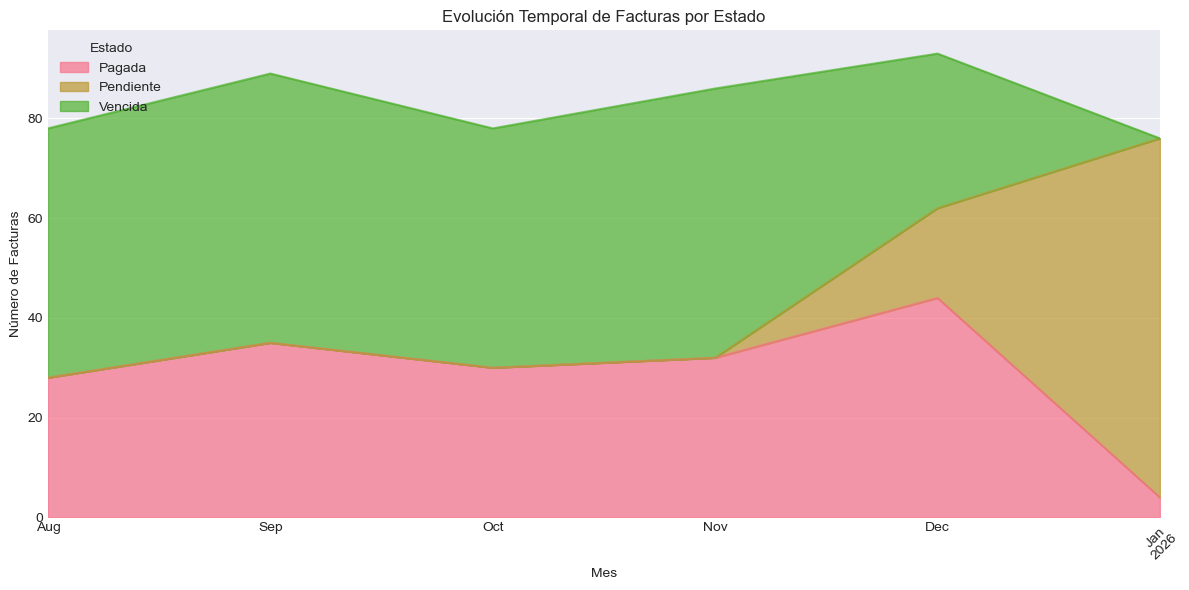

✅ Gráfico temporal generado


In [20]:
print("\n" + "-" * 60)
print("📊 VISUALIZACIÓN 5: Evolución temporal")
print("-" * 60)

# Agrupar por mes de emisión
df_facturas['mes_emision'] = df_facturas['fecha_emision'].dt.to_period('M')

facturas_por_mes = df_facturas.groupby(['mes_emision', 'estado']).size().unstack(fill_value=0)

# Gráfico de líneas apiladas
plt.figure(figsize=(12, 6))
facturas_por_mes.plot(kind='area', stacked=True, alpha=0.7)
plt.xlabel('Mes')
plt.ylabel('Número de Facturas')
plt.title('Evolución Temporal de Facturas por Estado')
plt.legend(title='Estado', loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"✅ Gráfico temporal generado")


------------------------------------------------------------
📊 VISUALIZACIÓN 6: Matriz de correlación
------------------------------------------------------------


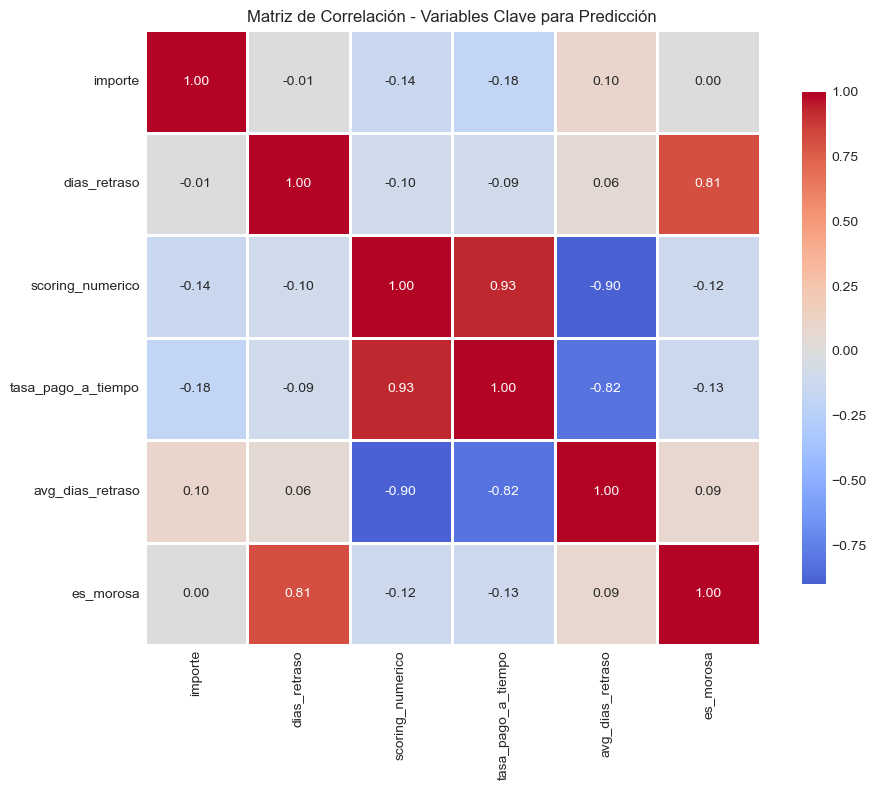


📊 Correlaciones más fuertes con 'es_morosa':
   dias_retraso: 0.810
   avg_dias_retraso: 0.087
   importe: 0.005
   scoring_numerico: -0.125
   tasa_pago_a_tiempo: -0.130


In [21]:
print("\n" + "-" * 60)
print("📊 VISUALIZACIÓN 6: Matriz de correlación")
print("-" * 60)

# Crear dataset con features numéricas
df_analisis = df_facturas.merge(df_clientes[['cliente_id', 'scoring_externo']], on='cliente_id')
df_analisis = df_analisis.merge(df_historial, on='cliente_id')

# Convertir scoring a numérico
scoring_map = {'Alto': 3, 'Medio': 2, 'Bajo': 1}
df_analisis['scoring_numerico'] = df_analisis['scoring_externo'].map(scoring_map)

# Convertir estado a binario (vencida = 1, resto = 0)
df_analisis['es_morosa'] = (df_analisis['estado'] == 'Vencida').astype(int)

# Seleccionar columnas numéricas relevantes
columnas_correlacion = [
    'importe', 
    'dias_retraso', 
    'scoring_numerico',
    'tasa_pago_a_tiempo',
    'avg_dias_retraso',
    'es_morosa'
]

# Matriz de correlación
correlacion = df_analisis[columnas_correlacion].corr()

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Clave para Predicción')
plt.tight_layout()
plt.show()

print("\n📊 Correlaciones más fuertes con 'es_morosa':")
correlaciones_morosa = correlacion['es_morosa'].drop('es_morosa').sort_values(ascending=False)
for var, corr in correlaciones_morosa.items():
    print(f"   {var}: {corr:.3f}")

In [26]:
print("\n" + "=" * 60)
print("🎯 INSIGHTS CLAVE PARA EL MODELO ML")
print("=" * 60)

# --- RECALCULAR VARIABLES SI NO EXISTEN ---

# 1. Recalcular morosidad_scoring (por si no se ejecutó celda 7)
try:
    morosidad_scoring
except NameError:
    print("⚠️  Recalculando morosidad_scoring...")
    df_facturas_scoring = df_facturas.merge(
        df_clientes[['cliente_id', 'scoring_externo']], 
        on='cliente_id'
    )
    morosidad_scoring = df_facturas_scoring.groupby('scoring_externo').apply(
        lambda x: (x['estado'] == 'Vencida').sum() / len(x) * 100
    )
    orden = ['Bajo', 'Medio', 'Alto']
    morosidad_scoring = morosidad_scoring.reindex(orden)

# 2. Recalcular morosidad_sector (por si no se ejecutó celda 5)
try:
    morosidad_sector
except NameError:
    print("⚠️  Recalculando morosidad_sector...")
    df_facturas_sector = df_facturas.merge(
        df_clientes[['cliente_id', 'sector']], 
        on='cliente_id'
    )
    morosidad_sector = df_facturas_sector.groupby('sector').apply(
        lambda x: (x['estado'] == 'Vencida').sum() / len(x) * 100
    ).sort_values(ascending=False)

# 3. Recalcular correlaciones_morosa (por si no se ejecutó celda 9)
try:
    correlaciones_morosa
except NameError:
    print("⚠️  Recalculando correlaciones...")
    df_analisis = df_facturas.merge(df_clientes[['cliente_id', 'scoring_externo']], on='cliente_id')
    df_analisis = df_analisis.merge(df_historial, on='cliente_id')
    scoring_map = {'Alto': 3, 'Medio': 2, 'Bajo': 1}
    df_analisis['scoring_numerico'] = df_analisis['scoring_externo'].map(scoring_map)
    df_analisis['es_morosa'] = (df_analisis['estado'] == 'Vencida').astype(int)
    columnas_correlacion = [
        'importe', 'dias_retraso', 'scoring_numerico',
        'tasa_pago_a_tiempo', 'avg_dias_retraso', 'es_morosa'
    ]
    correlacion = df_analisis[columnas_correlacion].corr()
    correlaciones_morosa = correlacion['es_morosa'].drop('es_morosa').sort_values(ascending=False)

# 4. Recalcular facturas_vencidas (por si no se ejecutó celda 6)
try:
    facturas_vencidas
except NameError:
    print("⚠️  Recalculando facturas_vencidas...")
    facturas_vencidas = df_facturas[df_facturas['estado'] == 'Vencida']

# --- FIN RECÁLCULOS ---

print("\n1️⃣ VARIABLES MÁS PREDICTIVAS (según correlación):")
top_correlaciones = correlaciones_morosa.head(3)
for i, (var, corr) in enumerate(top_correlaciones.items(), 1):
    print(f"   {i}. {var}: {corr:.3f}")

print("\n2️⃣ SEGMENTOS DE ALTO RIESGO:")
print(f"   • Scoring Bajo: {morosidad_scoring.get('Bajo', 0):.1f}% morosidad")
print(f"   • Sector con más morosidad: {morosidad_sector.index[0]} ({morosidad_sector.iloc[0]:.1f}%)")

print("\n3️⃣ PATRONES TEMPORALES:")
print(f"   • Días promedio de retraso: {facturas_vencidas['dias_retraso'].mean():.1f} días")
print(f"   • El 50% de facturas vencidas se retrasan menos de {facturas_vencidas['dias_retraso'].median():.0f} días")

print("\n4️⃣ DEUDA EN RIESGO:")
deuda_alto_riesgo = df_facturas[
    (df_facturas['estado'] == 'Vencida') & 
    (df_facturas['dias_retraso'] > facturas_vencidas['dias_retraso'].quantile(0.75))
]['importe'].sum()
print(f"   • Facturas con >75% días retraso: {deuda_alto_riesgo:,.2f}€")

print("\n5️⃣ FEATURES RECOMENDADAS PARA EL MODELO:")
features_recomendadas = [
    'importe',
    'dias_retraso',
    'scoring_externo (codificado)',
    'tasa_pago_a_tiempo',
    'avg_dias_retraso (histórico)',
    'sector (one-hot encoding)',
    'ratio_importe_vs_promedio'
]
for i, feature in enumerate(features_recomendadas, 1):
    print(f"   {i}. {feature}")

print("\n" + "=" * 60)
print("✅ ANÁLISIS EXPLORATORIO COMPLETADO")
print("   Siguiente paso: Feature Engineering y Modelo ML")
print("=" * 60)


🎯 INSIGHTS CLAVE PARA EL MODELO ML
⚠️  Recalculando morosidad_scoring...

1️⃣ VARIABLES MÁS PREDICTIVAS (según correlación):
   1. dias_retraso: 0.810
   2. avg_dias_retraso: 0.087
   3. importe: 0.005

2️⃣ SEGMENTOS DE ALTO RIESGO:
   • Scoring Bajo: 55.8% morosidad
   • Sector con más morosidad: Retail (51.9%)

3️⃣ PATRONES TEMPORALES:
   • Días promedio de retraso: 78.8 días
   • El 50% de facturas vencidas se retrasan menos de 81 días

4️⃣ DEUDA EN RIESGO:
   • Facturas con >75% días retraso: 199,498.66€

5️⃣ FEATURES RECOMENDADAS PARA EL MODELO:
   1. importe
   2. dias_retraso
   3. scoring_externo (codificado)
   4. tasa_pago_a_tiempo
   5. avg_dias_retraso (histórico)
   6. sector (one-hot encoding)
   7. ratio_importe_vs_promedio

✅ ANÁLISIS EXPLORATORIO COMPLETADO
   Siguiente paso: Feature Engineering y Modelo ML
